# ANALISIS EXPLORATORIO DE LOS DATOS


In [1]:


# ==== Librerías ====
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
sns.set(style="whitegrid")


## **Información general de los datos**

El conjunto de datos analizado contiene información académica y sociodemográfica de estudiantes universitarios, con un total de 4.424 registros y 37 variables. Estas variables incluyen datos numéricos (por ejemplo, edad, número de unidades curriculares aprobadas o reprobadas, promedio de calificaciones) y categóricos (por ejemplo, estado civil, tipo de curso, área de estudio).

In [2]:
csv_path = "data.csv"
df = pd.read_csv(csv_path, sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print(df.shape)

(4424, 37)


 Dimensiones (`df.shape`)
- **4,424 filas × 37 columnas** → tamaño medio; suficiente para KNN/Reg. Logística.
- **37 features** 



In [4]:
print(df.dtypes)

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

 Tipos de datos (`df.dtypes`)
- Predominan **int64** y algunas **float64**.  
- Varias `int64` son **códigos categóricos** (p. ej., *Marital status, Course, Debtor, International, Scholarship holder*)  
- Continuas clave: **Admission grade**, **Previous qualification (grade)**, **Inflation rate**, **GDP** 
- `Target` es `object`  
- vamos a renombrar `Daytime/evening attendance\t` (tiene *tab*) antes del modelado.  



In [5]:
print(df.isna().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

Nulos (`df.isna().sum()`)
- **0 nulos en todas las columnas**   



In [6]:
df.describe(include='all')

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


`describe()`
- Todas las columnas aparecen como **numéricas**, pero varias son **códigos categóricos** (p. ej., *Marital status, Course, Daytime/evening attendance*). 
- Variables claramente continuas: **Previous qualification (grade)** (95–190), **Admission grade**, etc.; muestran rangos amplios y posible **asimetría**, por lo que conviene **escalar/estandarizar** (especialmente para KNN).
- `Daytime/evening attendance` es binaria (0/1) con media ≈0.89 → mayoría **diurna/nocturna** según codificación.
- Varias métricas académicas por semestre tienen valores bajos/promedios pequeños (p. ej., *credited 2nd sem*)


In [7]:
dups = df.duplicated().sum()
print("\nFilas duplicadas:", dups)
if dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(" Duplicados eliminados. Nuevas dimensiones:", df.shape)


Filas duplicadas: 0


In [8]:
card = df.nunique().sort_values(ascending=False)
print("\nCardinalidad (valores únicos) por columna (top 15):")
print(card.head(15))


Cardinalidad (valores únicos) por columna (top 15):
Curricular units 1st sem (grade)          805
Curricular units 2nd sem (grade)          786
Admission grade                           620
Previous qualification (grade)            101
Father's occupation                        46
Age at enrollment                          46
Curricular units 1st sem (evaluations)     35
Father's qualification                     34
Mother's occupation                        32
Curricular units 2nd sem (evaluations)     30
Mother's qualification                     29
Curricular units 1st sem (enrolled)        23
Curricular units 1st sem (approved)        23
Curricular units 2nd sem (enrolled)        22
Curricular units 1st sem (credited)        21
dtype: int64


In [9]:
# Resumen de numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    print("Resumen estadístico de variables numéricas:")
    display(df[num_cols].describe().T)
else:
    print("No se detectaron columnas numéricas.")

Resumen estadístico de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000



Distribución de Target (conteo y %):


,conteo,porcentaje
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


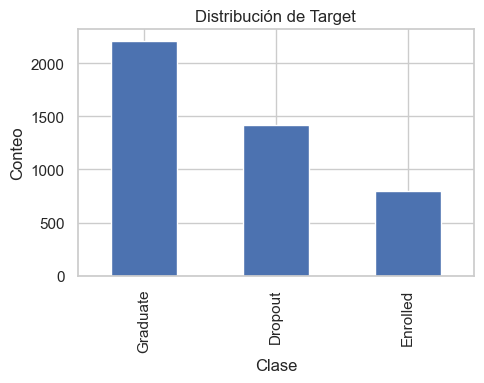

In [10]:
TARGET = "Target"
if TARGET in df.columns:
    vc = df[TARGET].value_counts(dropna=False)
    vp = df[TARGET].value_counts(normalize=True, dropna=False)*100
    print("\nDistribución de Target (conteo y %):")
    display(pd.DataFrame({"conteo": vc, "porcentaje": vp.round(2)}))

    plt.figure(figsize=(5,4))
    vc.plot(kind="bar")
    plt.title("Distribución de Target")
    plt.ylabel("Conteo")
    plt.xlabel("Clase")
    plt.tight_layout()
    plt.show()
else:
    raise ValueError(f"No se encontró la columna objetivo '{TARGET}'.")

### **Distribución de `Target`**
- **Graduate 49.93%**, **Dropout 32.12%**, **Enrolled 17.95%**  



In [ ]:
THRESH_HIGH = 0.75  # >75%: MUY desbalanceada
THRESH_MED  = 0.60  # 60-75%: desbalanceada (usable con técnicas)

def recomendacion_balance(vc_norm, thr_high=0.75, thr_med=0.60):
    mayoritaria = vc_norm.iloc[0]
    clase = vc_norm.index[0]
    if mayoritaria > thr_high:
        return f" variable muy desbalanceada (clase mayoritaria '{clase}' = {mayoritaria*100:.2f}%). Recomendación: NO USAR.", "no_usar"
    elif mayoritaria > thr_med:
        return (f"variable Desbalanceada (clase mayoritaria '{clase}' = {mayoritaria*100:.2f}%)." , "re_muestrear")
    else:
        return f"variable Balanceada (clase mayoritaria '{clase}' = {mayoritaria*100:.2f}%). Recomendación: USAR.", "usar"

# Opción: binarizar (Dropout vs resto) al estilo del EDA
MAP_TO_BINARY = True  

y = df[TARGET].copy()
if MAP_TO_BINARY:
    y = y.replace({"Enrolled": "No_dropout", "Graduate": "No_dropout"})


if np.issubdtype(y.dtype, np.number) and y.nunique() > 10:
    print("ℹ El Target parece continuo (regresión). El desbalance no aplica como en clasificación.")
else:
    vc_norm = y.value_counts(normalize=True)
    msg, tag = recomendacion_balance(vc_norm, THRESH_HIGH, THRESH_MED)
    print(msg)


variable Desbalanceada (clase mayoritaria 'No_dropout' = 67.88%).


### **Desbalance**
- Resultado: **Desbalanceada** (clase mayoritaria `No_dropout` = **67.88%**).
- **68%** no desertan vs ~**32%** desertan.



In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"# numéricas detectadas: {len(num_cols)}")
print(num_cols[:30])  # muestra las primeras 30, por si hay muchas


# numéricas detectadas: 36
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)']


Top variables por MI con Target:


Curricular units 2nd sem (approved)       0.310207
Curricular units 2nd sem (grade)          0.239324
Curricular units 1st sem (approved)       0.233439
Curricular units 1st sem (grade)          0.184882
Tuition fees up to date                   0.100460
Curricular units 2nd sem (evaluations)    0.096761
Curricular units 1st sem (evaluations)    0.075691
Age at enrollment                         0.065516
Course                                    0.053425
Curricular units 1st sem (enrolled)       0.052744
Application mode                          0.046571
Previous qualification (grade)            0.044584
dtype: float64

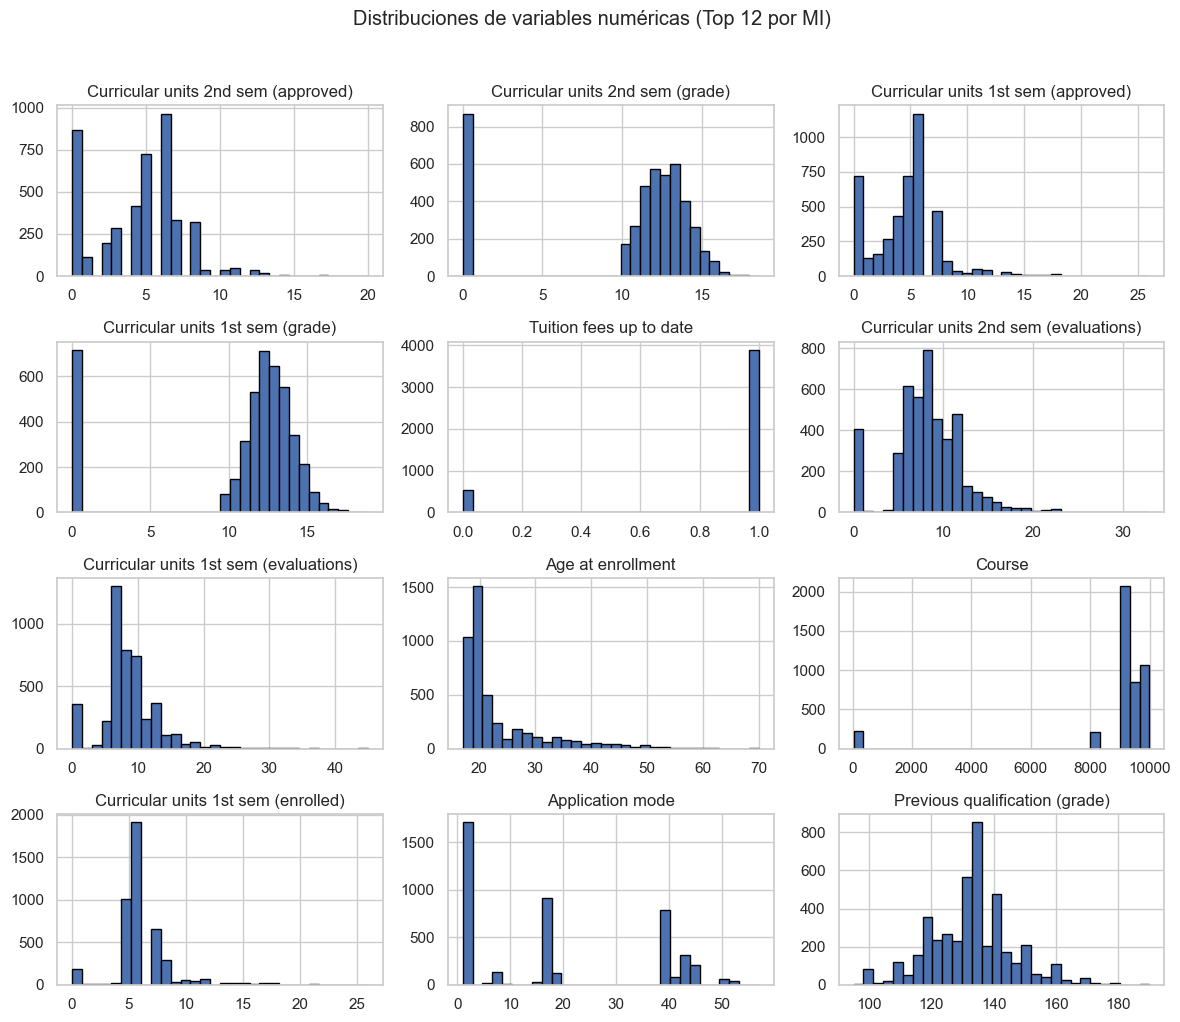

In [24]:
# --- Solo graficar las numéricas más importantes vs Target ---
from sklearn.feature_selection import mutual_info_classif
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N = 12  # cuántas columnas quieres graficar

# 1) columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if not num_cols:
    print("No hay columnas numéricas para evaluar.")
else:
    # 2) preparar X (numéricas) e y (códigos de la clase)
    X_num = df[num_cols].replace([np.inf, -np.inf], np.nan)
    X_num = X_num.fillna(X_num.median())  # solo para calcular MI
    y = df[TARGET].astype("category").cat.codes

    # 3) importancia por Mutual Information
    mi = mutual_info_classif(X_num, y, discrete_features=False, random_state=42)
    mi_series = pd.Series(mi, index=num_cols).sort_values(ascending=False)
    print("Top variables por MI con Target:")
    display(mi_series.head(TOP_N))

    # 4) graficar solo las TOP_N
    top_cols = mi_series.head(min(TOP_N, len(mi_series))).index.tolist()
    ax = df[top_cols].hist(bins=30, figsize=(12,10), edgecolor="black")
    plt.suptitle(f"Distribuciones de variables numéricas (Top {len(top_cols)} por MI)", y=1.02)
    plt.tight_layout()
    plt.show()



 Top 12 numéricas 
- Se repiten mucho las **curricular units** (approved/grade/evaluations/enrolled, 1º y 2º sem). Claramente son las que más se relacionan con el **Target**.  


- **Age at enrollment** está **sesgada** (muchos jóvenes). Para KNN conviene **escalar**.
- **Course** y **Application mode** tienen picos tipo **IDs** → son **categóricas**, no continuas (one-hot).

- En general, antes de KNN: **StandardScaler** sí o sí (hay escalas muy distintas).


In [15]:
numericas = df.select_dtypes(include=[np.number])
numericas.nunique()

Marital status                                      6
Application mode                                   18
Application order                                   8
Course                                             17
Daytime/evening attendance\t                        2
Previous qualification                             17
Previous qualification (grade)                    101
Nacionality                                        21
Mother's qualification                             29
Father's qualification                             34
Mother's occupation                                32
Father's occupation                                46
Admission grade                                   620
Displaced                                           2
Educational special needs                           2
Debtor                                              2
Tuition fees up to date                             2
Gender                                              2
Scholarship holder          

### **Verificación de normalidad**

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
def test_normalidad(df):
    """
    Aplica el test de normalidad Shapiro-Wilk a las variables numéricas de un DataFrame
    (válido para datasets con menos de 5000 registros).

    Parámetros:
    -----------
    df : pd.DataFrame
        Dataset de entrada.

    Retorna:
    --------
    pd.DataFrame con columnas:
        - Variable
        - Estadístico W
        - p-valor
        - Normalidad (Normal / No Normal / Datos insuficientes)
    """
    
    # Seleccionar solo variables numéricas
    numericas = df.select_dtypes(include=[np.number])

    if len(df) >= 5000:
        print("⚠️ El dataset tiene 5000 o más registros, el test de Shapiro no es recomendado.")
        return None
    
    n_cols = 2
    n_rows = int(np.ceil(len(numericas.columns) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten()  # Asegurar formato 1D para iterar

    for i, col in enumerate(numericas.columns):
        sns.boxplot(x=numericas[col], ax=axes[i], color="skyblue")
        axes[i].set_title(f"Diagrama de Caja - {col}", fontsize=12)
        axes[i].set_xlabel(col)

    # Eliminar ejes sobrantes si hay menos gráficos que subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    resultados = []

    for col in numericas.columns:
        datos = numericas[col].dropna()

        if len(datos) > 3:  # Shapiro requiere al menos 3 valores
            stat, p = shapiro(datos)
            normalidad = "Normal" if p > 0.05 else "No Normal"
            resultados.append([col, stat, p, normalidad])
        else:
            resultados.append([col, None, None, "Datos insuficientes"])

    resultados_df = pd.DataFrame(resultados, 
                                 columns=["Variable", "Estadístico W", "p-valor", "Normalidad"])
    return resultados_df

C:\Users\franc\AppData\Local\Temp\ipykernel_11256\4162327466.py:45: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\franc\anaconda3\envs\ml_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


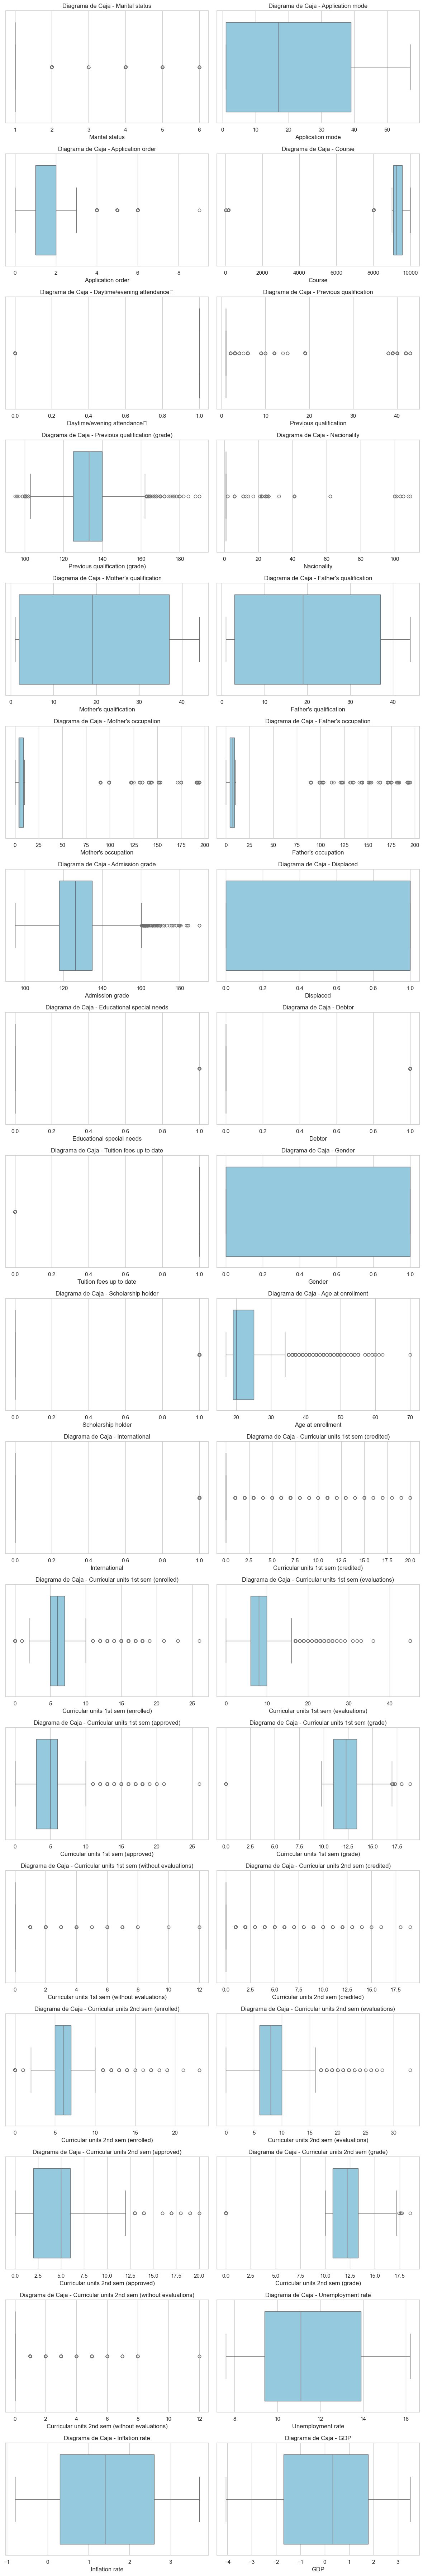

,Variable,Estadístico W,p-valor,Normalidad
0,Marital status,0.325647,1.113040e-83,No Normal
1,Application mode,0.809773,3.489577e-58,No Normal
2,Application order,0.619069,1.378633e-71,No Normal
3,Course,0.391875,2.026925e-81,No Normal
4,Daytime/evening attendance\t,0.359607,1.514561e-82,No Normal
5,Previous qualification,0.386257,1.279505e-81,No Normal
6,Previous qualification (grade),0.979897,1.443189e-24,No Normal
7,Nacionality,0.106444,5.395942e-90,No Normal
8,Mother's qualification,0.794115,1.224245e-59,No Normal
9,Father's qualification,0.785018,1.926982e-60,No Normal


In [13]:
resultado = test_normalidad(df)
resultado